In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Downloads123\NCUA_Auto_Loan_Data\auto_loans_final.csv")
print(df.columns.tolist())
print(df.dtypes)
print(df.head())
print(df['CYCLE_DATE'].unique())

['CU_NUMBER', 'CYCLE_DATE', 'ACCT_021C', 'ACCT_021D', 'ACCT_020C1', 'ACCT_020C2']
CU_NUMBER      int64
CYCLE_DATE    object
ACCT_021C      int64
ACCT_021D      int64
ACCT_020C1     int64
ACCT_020C2     int64
dtype: object
   CU_NUMBER CYCLE_DATE  ACCT_021C  ACCT_021D  ACCT_020C1  ACCT_020C2
0          1    2024-03          0          0       44395       39902
1          6    2024-03          0          0      331491     1423742
2         12    2024-03          0          0       38928       21390
3         13    2024-03          0          0     4812056     5497039
4         16    2024-03          0          0           0           0
['2024-03' '2024-06' '2024-09' '2024-12' '2025-03' '2025-06' '2025-09'
 '2025-12']


In [2]:
df['total_delinq'] = df['ACCT_021C'] + df['ACCT_021D']
df['total_auto']   = df['ACCT_020C1'] + df['ACCT_020C2']

quarterly = df.groupby('CYCLE_DATE')[['total_delinq', 'total_auto']].sum()
quarterly['delinq_rate'] = quarterly['total_delinq'] / quarterly['total_auto']

print(quarterly)

            total_delinq  total_auto  delinq_rate
CYCLE_DATE                                       
2024-03          9749816  6507553209     0.001498
2024-06          9712714  6873554588     0.001413
2024-09         10584477  6989422358     0.001514
2024-12         10330106  7818046864     0.001321
2025-03          8063377  6693818042     0.001205
2025-06          8077610  6693075453     0.001207
2025-09          9427408  6846676623     0.001377
2025-12          9366157  7796273480     0.001201


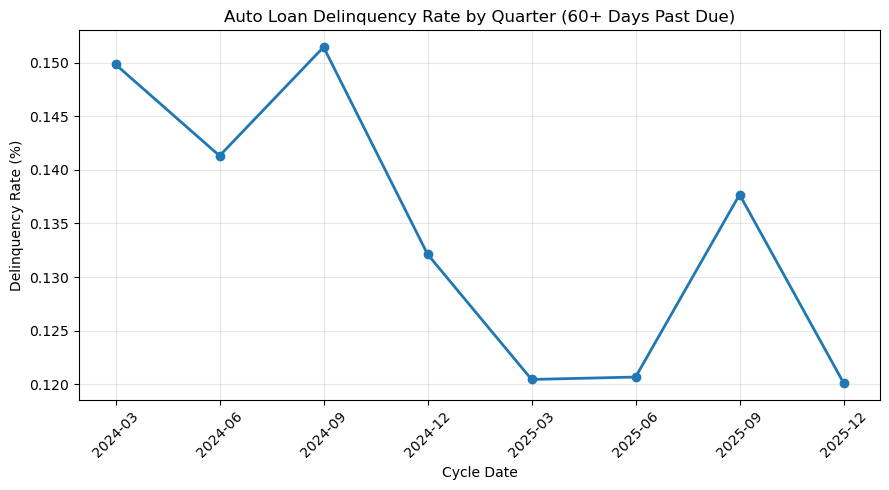

In [3]:
import matplotlib.pyplot as plt

quarterly['delinq_rate_pct'] = quarterly['delinq_rate'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(quarterly.index, quarterly['delinq_rate_pct'], marker='o', linewidth=2)
ax.set_title('Auto Loan Delinquency Rate by Quarter (60+ Days Past Due)')
ax.set_ylabel('Delinquency Rate (%)')
ax.set_xlabel('Cycle Date')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('delinquency_trend.png', dpi=150)
plt.show()

In [4]:
# Average auto loan portfolio size per CU across all quarters
cu_size = df.groupby('CU_NUMBER')['total_auto'].mean().reset_index()
cu_size.columns = ['CU_NUMBER', 'avg_auto_balance']

# Bucket into size cohorts using quartiles
cu_size['size_cohort'] = pd.qcut(
    cu_size['avg_auto_balance'],
    q=4,
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

# Merge cohort back onto main df
df = df.merge(cu_size[['CU_NUMBER', 'size_cohort']], on='CU_NUMBER')

# Delinquency rate by cohort
cohort_summary = df.groupby('size_cohort')[['total_delinq', 'total_auto']].sum()
cohort_summary['delinq_rate_pct'] = (cohort_summary['total_delinq'] / cohort_summary['total_auto']) * 100

print(cohort_summary)

             total_delinq   total_auto  delinq_rate_pct
size_cohort                                            
Small                   0     55312879         0.000000
Medium                  0    521313273         0.000000
Large               79907   2460065996         0.003248
Very Large       75231758  53181728469         0.141462


C:\Users\shake\AppData\Local\Temp\ipykernel_1720\1617263426.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_summary = df.groupby('size_cohort')[['total_delinq', 'total_auto']].sum()


In [5]:
check = df.groupby('size_cohort', observed=True).agg(
    cu_count=('CU_NUMBER', 'nunique'),
    zero_delinq_pct=('total_delinq', lambda x: (x == 0).mean() * 100)
)
print(check)

             cu_count  zero_delinq_pct
size_cohort                           
Small            1176       100.000000
Medium           1175       100.000000
Large            1175        99.978085
Very Large       1176        96.711314


In [6]:
# Which CUs actually report non-zero delinquency, and how concentrated is it?
cu_delinq = df.groupby('CU_NUMBER')['total_delinq'].sum().reset_index()
cu_delinq = cu_delinq[cu_delinq['total_delinq'] > 0].sort_values('total_delinq', ascending=False)

print(f"CUs with any reported delinquency: {len(cu_delinq)} out of {df['CU_NUMBER'].nunique()}")
print(f"Top 10 CUs account for: {cu_delinq['total_delinq'].head(10).sum() / cu_delinq['total_delinq'].sum() * 100:.1f}% of all delinquency")
print(cu_delinq.head(10))

CUs with any reported delinquency: 56 out of 4702
Top 10 CUs account for: 73.5% of all delinquency
      CU_NUMBER  total_delinq
1852      15732      11950521
2462      23279      11457410
585        4735       8366691
978        8116       6680524
2557      24224       3813237
4408      68434       3156813
4565      68705       2967187
4572      68712       2606426
2006      17429       2453828
4334      68251       1870579


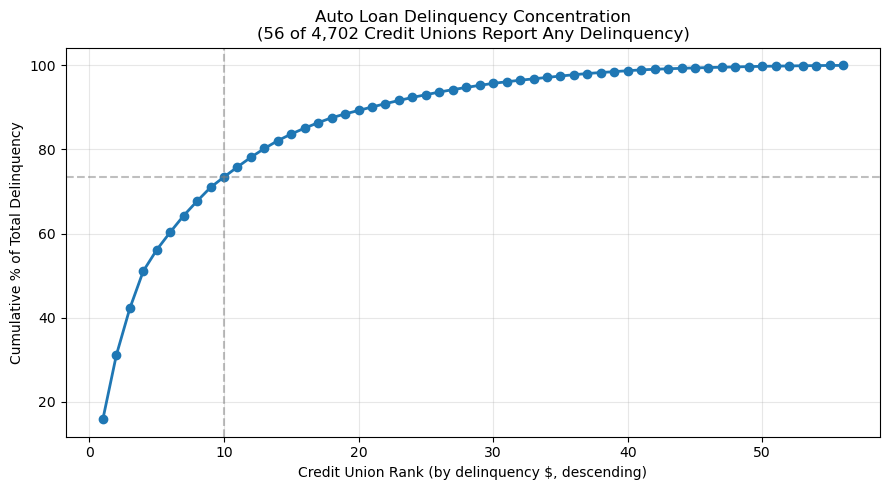

In [7]:
cu_delinq_sorted = cu_delinq.sort_values('total_delinq', ascending=False).reset_index(drop=True)
cu_delinq_sorted['cumulative_pct'] = cu_delinq_sorted['total_delinq'].cumsum() / cu_delinq_sorted['total_delinq'].sum() * 100
cu_delinq_sorted['cu_rank'] = range(1, len(cu_delinq_sorted) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cu_delinq_sorted['cu_rank'], cu_delinq_sorted['cumulative_pct'], marker='o', linewidth=2)
ax.axhline(73.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(10, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Auto Loan Delinquency Concentration\n(56 of 4,702 Credit Unions Report Any Delinquency)')
ax.set_xlabel('Credit Union Rank (by delinquency $, descending)')
ax.set_ylabel('Cumulative % of Total Delinquency')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('delinquency_concentration.png', dpi=150)
plt.show()